## 1.Выбор набора данных
Выберем набор данных из второй лабораторной

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline 
sns.set(style="ticks")
seed = 13
np.random.seed(seed)

# Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных.
Цель лабораторной работы: изучение способов предварительной обработки данных для дальнейшего формирования моделей.

Для заданиябыл выбран датасет "Сравнение данных магнитно-резонансной томографии у взрослых с деменцией и без нее"
https://www.kaggle.com/datasets/jboysen/mri-and-alzheimers

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [2]:
data = pd.read_csv('data/oasis_cross-sectional.csv', sep=",")

In [3]:
print(data.shape)
print(data.dtypes)

(436, 12)
ID           str
M/F          str
Hand         str
Age        int64
Educ     float64
SES      float64
MMSE     float64
CDR      float64
eTIV       int64
nWBV     float64
ASF      float64
Delay    float64
dtype: object


In [4]:
data.describe()

,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
count,436.000000,235.000000,216.000000,235.00000,235.000000,436.000000,436.000000,436.000000,20.00000
mean,51.357798,3.178723,2.490741,27.06383,0.285106,1481.919725,0.791670,1.198894,20.55000
std,25.269862,1.311510,1.120593,3.69687,0.383405,158.740866,0.059937,0.128682,23.86249
min,18.000000,1.000000,1.000000,14.00000,0.000000,1123.000000,0.644000,0.881000,1.00000
25%,23.000000,2.000000,2.000000,26.00000,0.000000,1367.750000,0.742750,1.111750,2.75000
50%,54.000000,3.000000,2.000000,29.00000,0.000000,1475.500000,0.809000,1.190000,11.00000
75%,74.000000,4.000000,3.000000,30.00000,0.500000,1579.250000,0.842000,1.284250,30.75000
max,96.000000,5.000000,5.000000,30.00000,2.000000,1992.000000,0.893000,1.563000,89.00000


In [5]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 436


# Обработка пропусков в данных

В колонке Delay отсутсвуют практически все данные, ее можно целиком удалить из датасета

In [6]:
data = data.drop(columns=["Delay"])
data.isnull().sum()

ID        0
M/F       0
Hand      0
Age       0
Educ    201
SES     220
MMSE    201
CDR     201
eTIV      0
nWBV      0
ASF       0
dtype: int64

Обработаем пропущенные числовые данные при помощи импьютации

In [31]:
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Educ. Тип данных float64. Количество пустых значений 201, 46.1%.
Колонка SES. Тип данных float64. Количество пустых значений 220, 50.46%.
Колонка MMSE. Тип данных float64. Количество пустых значений 201, 46.1%.
Колонка CDR. Тип данных float64. Количество пустых значений 201, 46.1%.


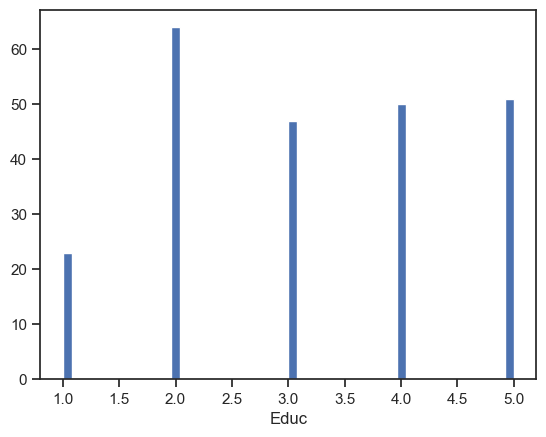

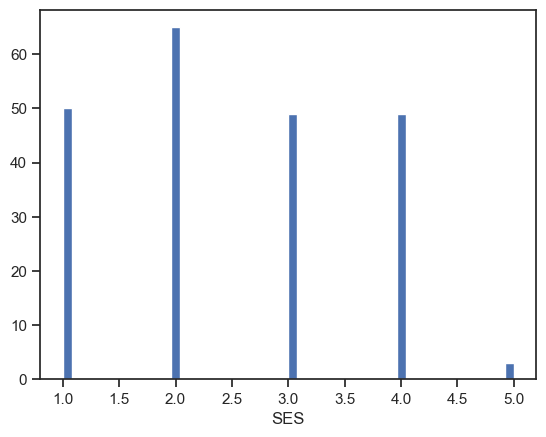

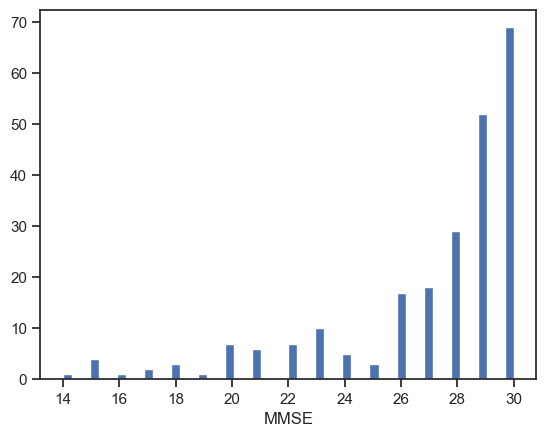

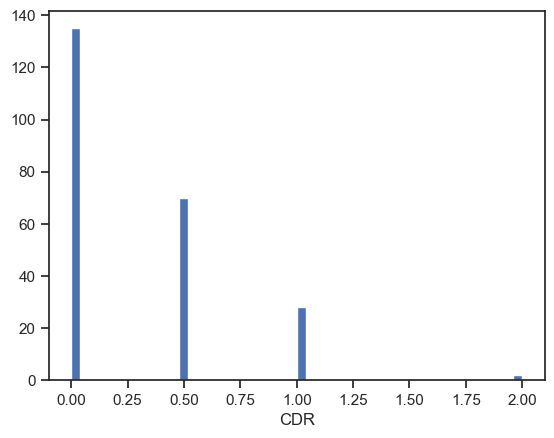

In [8]:
# Гистограмма по признакам
data_num = data[num_cols]
for col in data_num:
    plt.hist(data[col], 50)
    plt.xlabel(col)
    plt.show()

In [9]:
data_num_Educ = data_num[['Educ']]
data_num_Educ.head()

,Educ
0,2.0
1,4.0
2,4.0
3,NaN
4,NaN


In [10]:
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

In [11]:
indicator = MissingIndicator()
mask_missing_values_only = indicator.fit_transform(data_num_Educ)
strategies=['mean', 'median', 'most_frequent']

In [12]:
def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num_Educ)
    return data_num_imp[mask_missing_values_only]

In [13]:
strategies[0], test_num_impute(strategies[0])

('mean',
 array([3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234,
        3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234,
        3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234,
        3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234,
        3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234,
        3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234,
        3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234,
        3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234,
        3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234,
        3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234,
        3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234,
        3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234,
        3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234, 3.1787234,
        3.1787234, 3.1787234,

In [14]:
strategies[1], test_num_impute(strategies[1])

('median',
 array([3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.]))

In [15]:
strategies[2], test_num_impute(strategies[2])

('most_frequent',
 array([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.]))

In [16]:
def test_num_impute_col(dataset, column, strategy_param):
    temp_data = dataset[[column]]
    
    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)
    
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(temp_data)
    
    filled_data = data_num_imp[mask_missing_values_only]
    
    return column, strategy_param, filled_data.size, filled_data[0], filled_data[filled_data.size-1]

In [17]:
def impute_column(dataset, column, strategy_param, fill_value_param=None):
    """
    Заполнение пропусков в одном признаке
    """
    temp_data = dataset[[column]].values
    size = temp_data.shape[0]
    
    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)
    
    imputer = SimpleImputer(strategy=strategy_param, 
                            fill_value=fill_value_param)
    all_data = imputer.fit_transform(temp_data)
    
    missed_data = temp_data[mask_missing_values_only]
    filled_data = all_data[mask_missing_values_only]
    
    return all_data.reshape((size,)), filled_data, missed_data

In [18]:
def research_impute_numeric_column(dataset, num_column, const_value=None):
    strategy_params = ['mean', 'median', 'most_frequent', 'constant']
    strategy_params_names = ['Среднее', 'Медиана', 'Мода']
    strategy_params_names.append('Константа = ' + str(const_value))
    
    original_temp_data = dataset[[num_column]].values
    size = original_temp_data.shape[0]
    original_data = original_temp_data.reshape((size,))
    
    new_df = pd.DataFrame({'Исходные данные':original_data})
       
    for i in range(len(strategy_params)):
        strategy = strategy_params[i]
        col_name = strategy_params_names[i]
        if (strategy!='constant') or (strategy == 'constant' and const_value!=None):
            if strategy == 'constant':
                temp_data, _, _ = impute_column(dataset, num_column, strategy, fill_value_param=const_value)
            else:
                temp_data, _, _ = impute_column(dataset, num_column, strategy)
            new_df[col_name] = temp_data
        
    sns.kdeplot(data=new_df)

In [19]:
data[['MMSE']].describe()

,MMSE
count,235.00000
mean,27.06383
std,3.69687
min,14.00000
25%,26.00000
50%,29.00000
75%,30.00000
max,30.00000


In [20]:
test_num_impute_col(data, 'MMSE', strategies[0])

('MMSE',
 'mean',
 201,
 np.float64(27.06382978723404),
 np.float64(27.06382978723404))

In [21]:
test_num_impute_col(data, 'MMSE', strategies[1])

('MMSE', 'median', 201, np.float64(29.0), np.float64(29.0))

In [22]:
test_num_impute_col(data, 'MMSE', strategies[2])

('MMSE', 'most_frequent', 201, np.float64(30.0), np.float64(30.0))

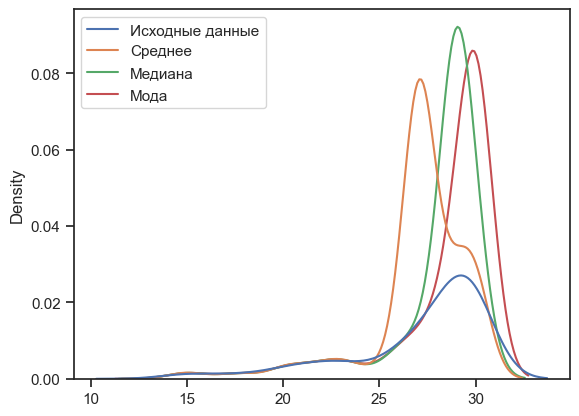

In [23]:
research_impute_numeric_column(data, 'MMSE')

# Преобразование категориальных признаков в числовые

In [24]:
cat_enc = pd.DataFrame({'c1':data.T[0]})
cat_enc

,c1
ID,OAS1_0001_MR1
M/F,F
Hand,R
Age,74
Educ,2.0
SES,3.0
MMSE,29.0
CDR,0.0
eTIV,1344
nWBV,0.743


In [25]:
data = data.drop(columns=['ID'])

# Посмотрим на оставшиеся категориальные колонки
cat_cols = ['M/F', 'Hand']
print("Уникальные значения в категориальных признаках:")
for col in cat_cols:
    print(f"{col}: {data[col].unique()}")

Уникальные значения в категориальных признаках:
M/F: <StringArray>
['F', 'M']
Length: 2, dtype: str
Hand: <StringArray>
['R']
Length: 1, dtype: str


Значения пола можно преобразовать в 0 или 1, а поскольку в признаке Hand только одно уникальное значение весь признак ничего не дает нам как и ID

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

data = data.drop(columns=['Hand'])

print(data.head())

   M/F  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF
0    0   74   2.0  3.0  29.0  0.0  1344  0.743  1.306
1    0   55   4.0  1.0  29.0  0.0  1147  0.810  1.531
2    0   73   4.0  3.0  27.0  0.5  1454  0.708  1.207
3    1   28   NaN  NaN   NaN  NaN  1588  0.803  1.105
4    1   18   NaN  NaN   NaN  NaN  1737  0.848  1.010


## Масштабирование признаков

In [27]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Сохраним названия колонок
features = data.columns

Попробуем два метода масшатбирования

1. Нормализация (MinMaxScaler)
Приводит все значения в диапазон от 0 до 1 (или от -1 до 1 при наличии отрицательных)

In [28]:
min_max_scaler = MinMaxScaler()
data_minmax = min_max_scaler.fit_transform(data)
data_minmax_df = pd.DataFrame(data_minmax, columns=features)

2. Масштабирование данных на основе Z-оценки (StandardScaler)
Центрирует распределение (среднее = 0) и делает стандартное отклонение равным 1.

In [29]:
std_scaler = StandardScaler()
data_std = std_scaler.fit_transform(data)
data_std_df = pd.DataFrame(data_std, columns=features)

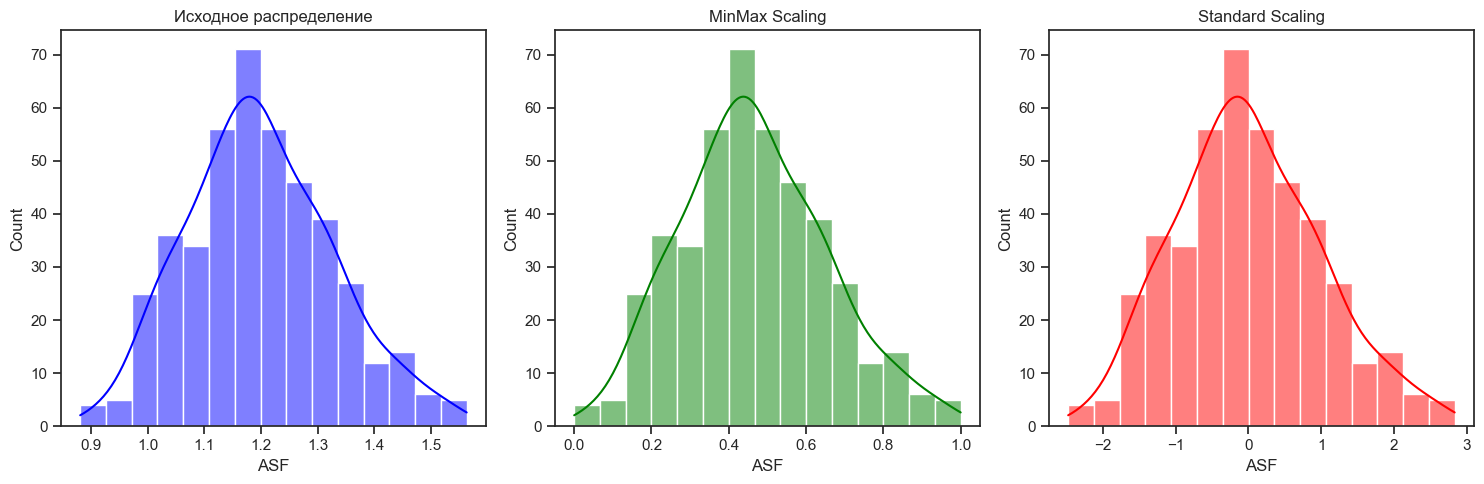

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(data['ASF'], ax=axes[0], kde=True, color='blue')
axes[0].set_title('Исходное распределение')

sns.histplot(data_minmax_df['ASF'], ax=axes[1], kde=True, color='green')
axes[1].set_title('MinMax Scaling')

sns.histplot(data_std_df['ASF'], ax=axes[2], kde=True, color='red')
axes[2].set_title('Standard Scaling')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Предполагается, что переменная data содержит датасет без пропусков и с закодированными категориями
# (результат выполнения предыдущей лабораторной)

# Отделяем целевую переменную (MMSE) от признаков
X = data.drop(columns=['MMSE'])
y = data['MMSE']

# Масштабируем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Разделяем выборку на обучающую (80%) и тестовую (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

In [2]:
data = pd.read_csv('data/oasis_cross-sectional.csv', sep=",")
data.describe()

,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
count,436.000000,235.000000,216.000000,235.00000,235.000000,436.000000,436.000000,436.000000,20.00000
mean,51.357798,3.178723,2.490741,27.06383,0.285106,1481.919725,0.791670,1.198894,20.55000
std,25.269862,1.311510,1.120593,3.69687,0.383405,158.740866,0.059937,0.128682,23.86249
min,18.000000,1.000000,1.000000,14.00000,0.000000,1123.000000,0.644000,0.881000,1.00000
25%,23.000000,2.000000,2.000000,26.00000,0.000000,1367.750000,0.742750,1.111750,2.75000
50%,54.000000,3.000000,2.000000,29.00000,0.000000,1475.500000,0.809000,1.190000,11.00000
75%,74.000000,4.000000,3.000000,30.00000,0.500000,1579.250000,0.842000,1.284250,30.75000
max,96.000000,5.000000,5.000000,30.00000,2.000000,1992.000000,0.893000,1.563000,89.00000


## 2. Удаление или заполнение пропусков и кодирование категориальных признаков.

In [3]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [4]:
# Удаляем неинформативные колонки и колонку с пустыми значениями
data = data.drop(columns=['ID', 'Delay', 'Hand'])

# Заполняем пропуски (используем медиану для числовых данных)
cols_to_impute = ['Educ', 'SES', 'MMSE', 'CDR']
imputer = SimpleImputer(strategy='median')
data[cols_to_impute] = imputer.fit_transform(data[cols_to_impute])

# Кодирование категориального признака пола
le = LabelEncoder()
data['M/F'] = le.fit_transform(data['M/F'])

In [5]:
# Формируем целевой признак (y) и матрицу признаков (X)
# Если CDR > 0, значит деменция есть (класс 1), иначе - здоров (класс 0)
y = (data['CDR'] > 0).astype(int)
X = data.drop(columns=['CDR'])

# Масштабирование признаков
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

display(X_scaled.head(3))

,M/F,Age,Educ,SES,MMSE,eTIV,nWBV,ASF
0,0.0,0.717949,0.25,0.5,0.9375,0.254315,0.397590,0.623167
1,0.0,0.474359,0.75,0.0,0.9375,0.027618,0.666667,0.953079
2,0.0,0.705128,0.75,0.5,0.8125,0.380898,0.257028,0.478006


## 3. С использованием метода train_test_split разделите выборку на обучающую и тестовую.

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=seed, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

Обучающая выборка: 305 строк
Тестовая выборка: 131 строк


## 4. Обучение моделей

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

### 1. Случайный лес
### 2. Сверхслучайные деревья
### 3. AdaBoost
### 4. Градиентный бустинг

In [9]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=seed)

et_model = ExtraTreesClassifier(n_estimators=100, random_state=seed)

ada_model = AdaBoostClassifier(n_estimators=100, random_state=seed)

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=seed)

models = {
    'Random Forest': rf_model,
    'Extra Trees': et_model,
    'AdaBoost': ada_model,
    'Gradient Boosting': gb_model
}

# Обучаем все модели
for name, model in models.items():
    model.fit(X_train, y_train)

## 5. Оценка качества и сравнение моделей

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [11]:
results =[]

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Расчет метрик
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Модель': name, 
        'Accuracy': acc, 
        'Precision': prec, 
        'Recall': rec, 
        'F1-Score': f1,
    })
    
    # Вывод матрицы ошибок для каждой модели
    print(f"\nМатрица ошибок для {name}:")
    print(confusion_matrix(y_test, y_pred))

# Сравнение в виде таблицы
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).set_index('Модель')
display(results_df.sort_values(by='F1-Score', ascending=False))


Матрица ошибок для Random Forest:
[[94  7]
 [11 19]]

Матрица ошибок для Extra Trees:
[[94  7]
 [ 8 22]]

Матрица ошибок для AdaBoost:
[[92  9]
 [ 9 21]]

Матрица ошибок для Gradient Boosting:
[[88 13]
 [ 6 24]]


,Accuracy,Precision,Recall,F1-Score
Модель,,,,
Extra Trees,0.885496,0.884252,0.885496,0.884808
AdaBoost,0.862595,0.862595,0.862595,0.862595
Gradient Boosting,0.854962,0.870326,0.854962,0.859935
Random Forest,0.862595,0.857573,0.862595,0.859022


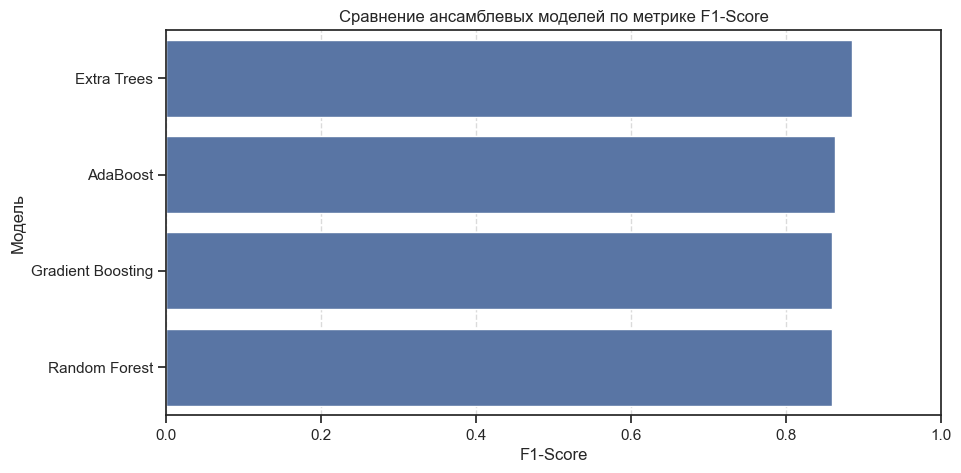

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(x='F1-Score', y='Модель', data=results_df)
plt.title('Сравнение ансамблевых моделей по метрике F1-Score')
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()